In [1]:
import os
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
from torch.amp import GradScaler, autocast
import matplotlib.pyplot as plt

# Fixed seed so weight init, shuffling and augmentation are repeatable
torch.manual_seed(42)

# Device configuration: NVIDIA GPU (Kaggle/Colab) -> Apple Silicon GPU -> CPU
if torch.cuda.is_available():
    device = torch.device("cuda:0")
    torch.backends.cudnn.benchmark = True
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

# Mixed precision only helps on CUDA; MPS and CPU train in float32
use_amp = device.type == 'cuda'
print(f"Accelerating on: {device} (AMP: {use_amp})")

Accelerating on: mps (AMP: False)


In [2]:
# RAF-DB colour dataset laid out as <data_dir>/train/1..7 and <data_dir>/test/1..7
# Uses the Kaggle input when running on Kaggle, otherwise the local copy in ../data/raf-db
kaggle_dir = '/kaggle/input/datasets/shuvoalok/raf-db-dataset/DATASET'
data_dir = kaggle_dir if os.path.isdir(kaggle_dir) else '../data/raf-db'

# Notice: Grayscale is REMOVED because RAF-DB provides high-quality RGB images
data_transforms = {
    'train': transforms.Compose([
        # Random zoom: crop 85-100% of the face, then resize to the model input
        transforms.RandomResizedCrop(224, scale=(0.85, 1.0), ratio=(0.9, 1.1)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        # Lighting varies a lot between in-the-wild photos
        transforms.ColorJitter(brightness=0.3, contrast=0.3),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        # Random occlusion, like hands, hair or glasses covering part of the face
        transforms.RandomErasing(p=0.25)
    ]),
    'test': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

image_datasets = {x: datasets.ImageFolder(f'{data_dir}/{x}', data_transforms[x]) for x in ['train', 'test']}
dataloaders = {
    x: DataLoader(image_datasets[x], batch_size=64, shuffle=(x == 'train'), num_workers=2,
                  pin_memory=use_amp, persistent_workers=True)
    for x in ['train', 'test']
}

class_names = image_datasets['train'].classes
# RAF-DB label meanings for folders '1'..'7' (same order as the video inference scripts)
emotion_names = ['Surprise', 'Fear', 'Disgust', 'Happy', 'Sad', 'Anger', 'Neutral']
print(f"Detected Classes: {class_names}")
print(f"Train images: {len(image_datasets['train'])}, Test images: {len(image_datasets['test'])}")

Detected Classes: ['1', '2', '3', '4', '5', '6', '7']
Train images: 12271, Test images: 3068


In [3]:
# Load Pretrained DenseNet-121
model = models.densenet121(weights='DEFAULT')

# DenseNet uses 'classifier' instead of 'fc'
num_ftrs = model.classifier.in_features

# Add Dropout to prevent overfitting, just like we did for ResNet
model.classifier = nn.Sequential(
    nn.Dropout(p=0.5),
    nn.Linear(num_ftrs, len(class_names)) 
)

model = model.to(device)

In [4]:
epochs = 12
criterion = nn.CrossEntropyLoss(label_smoothing=0.1) # Label smoothing handles noisy labels in datasets

# Upgraded from SGD to AdamW for faster and more stable convergence
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.01)

scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=1e-3, 
    steps_per_epoch=len(dataloaders['train']), 
    epochs=epochs
)

In [5]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=15):
    # With enabled=False (MPS/CPU) the scaler and autocast are no-ops
    scaler = GradScaler(device.type, enabled=use_amp)
    total_steps_limit = num_epochs * len(dataloaders['train'])
    current_step = 0

    history = {'train_loss': [], 'test_loss': [], 'train_acc': [], 'test_acc': []}

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        epoch_start = time.time()
        for phase in ['train', 'test']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss, running_corrects = 0.0, 0

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    with autocast(device.type, enabled=use_amp):
                        outputs = model(inputs)
                        _, preds = torch.max(outputs, 1)
                        loss = criterion(outputs, labels)

                    if phase == 'train':
                        scaler.scale(loss).backward()

                        before_step_scale = scaler.get_scale()
                        scaler.step(optimizer)
                        scaler.update()

                        if current_step < total_steps_limit:
                            if scaler.get_scale() >= before_step_scale:
                                scheduler.step()
                                current_step += 1

                running_loss += loss.item() * inputs.size(0)
                # Count as a Python int: MPS does not support float64 tensors
                running_corrects += (preds == labels).sum().item()

            epoch_loss = running_loss / len(image_datasets[phase])
            epoch_acc = running_corrects / len(image_datasets[phase])

            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc)
            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
        print(f'Epoch time: {time.time() - epoch_start:.0f}s')

    return model, history

model, history = train_model(model, criterion, optimizer, scheduler, num_epochs=epochs)

Epoch 1/12


train Loss: 1.5309 Acc: 0.4775


test Loss: 1.1248 Acc: 0.6923
Epoch time: 319s
Epoch 2/12


train Loss: 1.1121 Acc: 0.6886


test Loss: 1.0199 Acc: 0.7435
Epoch time: 313s
Epoch 3/12


...

test Loss: 0.7439 Acc: 0.8680
Epoch time: 310s
Epoch 11/12


train Loss: 0.6257 Acc: 0.9292


test Loss: 0.7360 Acc: 0.8755
Epoch time: 313s
Epoch 12/12


train Loss: 0.6005 Acc: 0.9425


test Loss: 0.7297 Acc: 0.8745
Epoch time: 308s


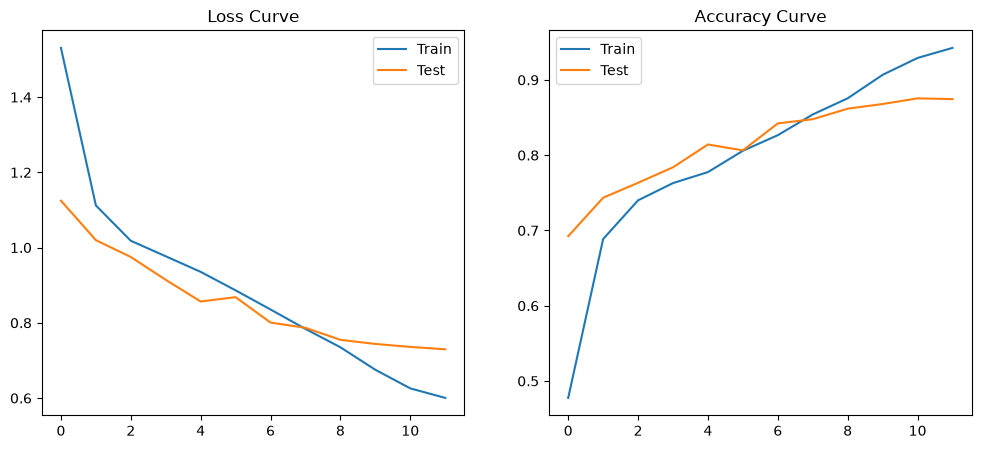

✅ RAF-DB Model saved successfully to 'densenet121_rafdb_final.pth'


In [6]:
# Plot Training History
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train')
plt.plot(history['test_loss'], label='Test')
plt.title('Loss Curve')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train')
plt.plot(history['test_acc'], label='Test')
plt.title('Accuracy Curve')
plt.legend()
plt.show()

# Save the RAF-DB trained model
torch.save(model.state_dict(), 'densenet121_rafdb_final.pth')
print("✅ RAF-DB Model saved successfully to 'densenet121_rafdb_final.pth'")

In [7]:
# Per-class accuracy on the RAF-DB test set
model.eval()
correct = torch.zeros(len(class_names), dtype=torch.long)
total = torch.zeros(len(class_names), dtype=torch.long)

with torch.no_grad():
    for inputs, labels in dataloaders['test']:
        preds = model(inputs.to(device)).argmax(1).cpu()
        total += torch.bincount(labels, minlength=len(class_names))
        correct += torch.bincount(labels[preds == labels], minlength=len(class_names))

print(f"Overall test accuracy: {correct.sum().item() / total.sum().item():.4f}\n")
for folder, name, c, t in zip(class_names, emotion_names, correct.tolist(), total.tolist()):
    print(f"{folder} {name:<9} {c / t:.4f}  ({c}/{t})")

Overall test accuracy: 0.8745

1 Surprise  0.8845  (291/329)
2 Fear      0.5405  (40/74)
3 Disgust   0.5437  (87/160)
4 Happy     0.9392  (1113/1185)
5 Sad       0.8787  (420/478)
6 Anger     0.8580  (139/162)
7 Neutral   0.8721  (593/680)
